# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [X] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [X] change OS to 1/10,
- [X] 1/10 OS and scf bop
- [ ] scaled bond integrals
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester

In [4]:
target_case = 'EF_fmbcc'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_case)

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [6]:
ModelName = 'Kernel Ridge'

# Targets

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


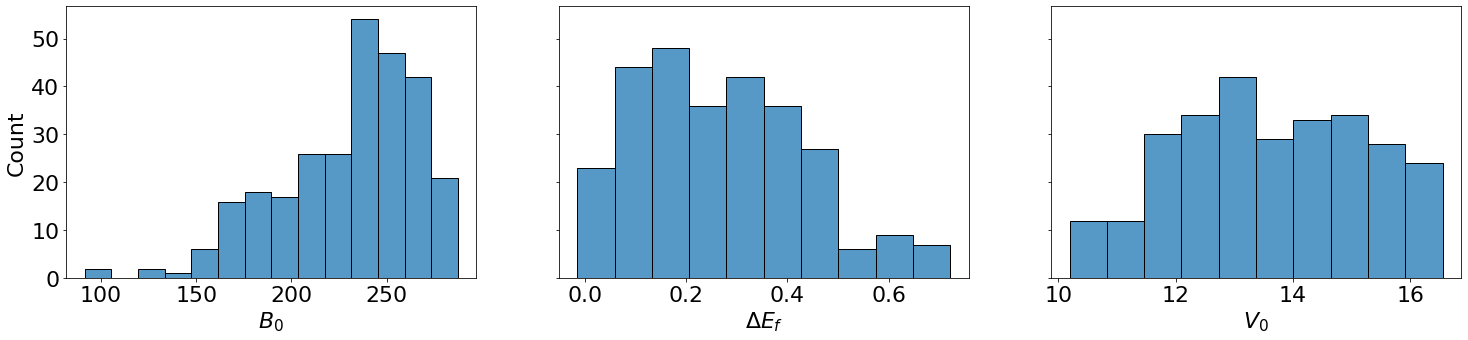

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_case], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

# Machine Learning 

In [8]:
from Tools.DatasetTools.MLConveniences import *

In [9]:
resultslocation = DS.resultslocation

## Feature sets

In [10]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [11]:
Features['ACE'] = Features['ACE_CNAV'].filter(regex='_0$|Mag|Structure')

## BOP features with and without CP averages

In [12]:
def clean_CNAVS(name: str, features: pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [13]:
def clean_zeros(name: str, features: pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [14]:
def notyetclean(name: str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [15]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name)})

In [16]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [17]:
samplesplit = DS.get_samplesplit()

(array([15., 15., 14.,  4.,  1.,  6.,  1.,  2.,  2.,  4.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

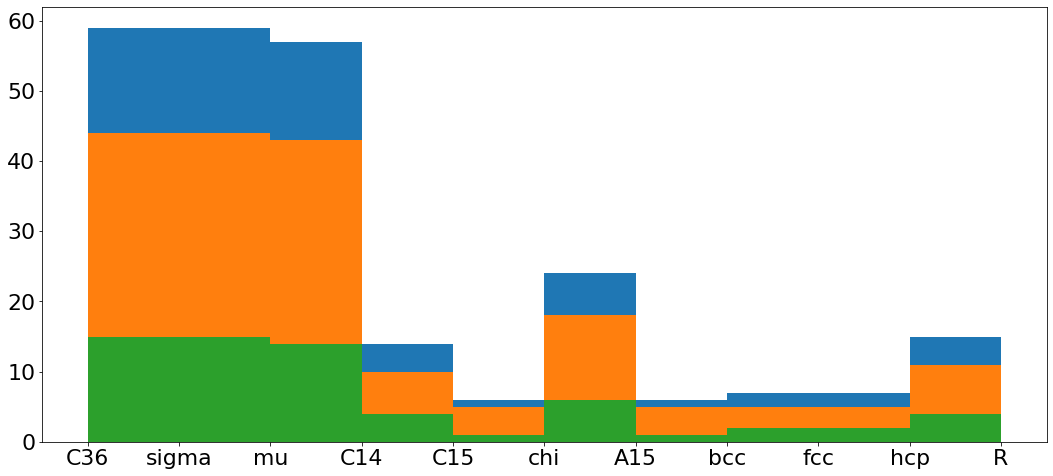

In [18]:
plt.hist(DS.StructureNames)

plt.hist(DS.StructureNames.loc[samplesplit['train']])
plt.hist(DS.StructureNames.loc[samplesplit['test']])

# Models: adjust params

In [19]:
import warnings
warnings.simplefilter('ignore')

In [20]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [21]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [22]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

# fits

In [23]:
ModelName

'Kernel Ridge'

In [24]:
# MO.save_model_options(ModelName, ModelOptions[ModelName])

MO.load_model_options(ModelName)

# MO.modeloptions[ModelName]

samplefolds = list(DS.get_folds())

fittedmodelslocation = os.path.join(DS.resultslocation, f'{ModelName}_{target_case}__FittedCVSearch.pkl')

if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)
else:
    FittedModels = {}
FittedModels = {}

In [25]:
non_fitted_model = {}

In [26]:
for name, model in Models.items():
    if name not in ModelName:
        print(name)
        continue
    progress = tqdm(Features.items())
    for key, features in progress:  # Features.items():
        progress.set_description(key)
#        if 'BOP' not in key:
#            continue
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        print(key)
        non_fitted_model[(name, key)] = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        model = copy.deepcopy(non_fitted_model[(name, key)])
        FittedModels[(name, key)] = model.fit(features, DS.target)

with open(fittedmodelslocation, 'wb') as pkl:
    pickle.dump(FittedModels, pkl)

  0%|          | 0/24 [00:00<?, ?it/s]

atomic
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_canonicalFe
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_canonicalW
Fitting 5 folds for each of 96 candidates, totalling 480 fits
SOAP_specific
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Pyscal
Fitting 5 folds for each of 96 candidates, totalling 480 fits
ACE_CNAV
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Canonical BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections OS BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Projections sOS BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset + Canonical BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fits
dataset + Projections BOP
Fitting 5 folds for each of 96 candidates, totalling 480 fi

In [27]:
best_scores = collect_best_scores(FittedModels)

best_combi = best_scores.idxmin()['test']

best_combi

('Kernel Ridge', 'Projections OS BOP')

In [28]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [29]:
best_scores.loc[best_combi]

test     4.152405e-02
train    2.486144e-09
Name: (Kernel Ridge, Projections OS BOP), dtype: float64

(array([21., 42., 45., 41., 32., 32., 20.,  7.,  9.,  5.]),
 array([-0.01216104,  0.0637716 ,  0.13970424,  0.21563687,  0.29156951,
         0.36750215,  0.44343479,  0.51936742,  0.59530006,  0.6712327 ,
         0.74716534]),
 <BarContainer object of 10 artists>)

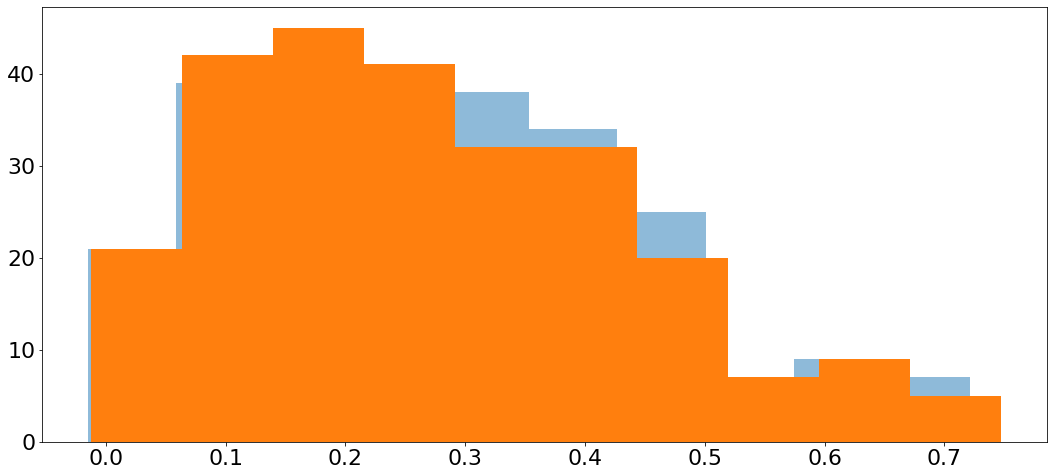

In [30]:
plt.hist(DS.target, alpha=0.5)
plt.hist(FittedModels[best_combi].predict(Features[best_combi[1]]))

for parameters in MO.modeloptions.values():
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

In [31]:
results = pd.DataFrame.from_dict(FittedModels[(ModelName, 'dataset + Projections OS BOP')].cv_results_)  # [['params','mean_test_score']]

In [32]:
results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_regressor__alpha', 'param_regressor__coef0',
       'param_regressor__degree', 'param_regressor__kernel', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

In [33]:
results.groupby('param_regressor__degree').max()['mean_test_score']

param_regressor__degree
4   -0.042229
5   -0.042389
6   -0.042902
7   -0.043146
Name: mean_test_score, dtype: float64

In [34]:
best_scores

test         train
Kernel Ridge Projections OS BOP             0.041524  2.486144e-09
             dataset + Projections OS BOP   0.042229  1.298372e-09
             SOAP_specific                  0.042320  1.930736e-09
             Projections BOP                0.050267  2.089054e-09
             dataset + Projections BOP      0.050338  7.714891e-10
             dataset + Projections sOS BOP  0.050507  7.909559e-10
             Projections sOS BOP            0.051596  2.301061e-09
             dataset + Canonical BOP        0.052908  9.192424e-08
             ACE                            0.054485  5.072156e-09
             ACE_CNAV                       0.056041  5.405434e-09
             dataset                        0.064353  5.693379e-10
             Canonical BOP                  0.073039  9.974298e-04
             SOAP_canonicalFe               0.164115  4.152683e-02
             SOAP_canonicalW                0.164115  4.152683e-02
             atomic                         0.172837  4.599695e-02
             Pyscal                         0.190410  1.102176e-01

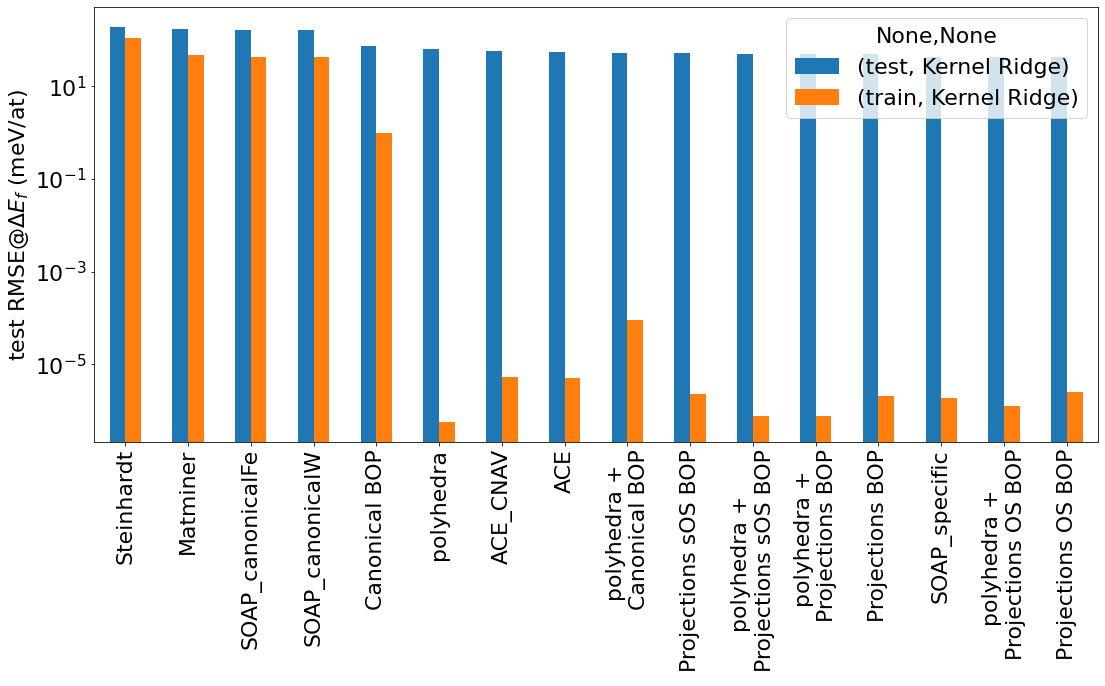

In [35]:
ax = plot_best_scores(best_scores, ModelName=ModelName)

# Recursivity

In [36]:
Tester = DatasetTester()

In [37]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# from Tools.DatasetTools.DatasetOperator import Dataset
# DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
# Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# samplesplit = DS.get_samplesplit()

In [38]:
import copy

In [39]:
RecursivityModels = copy.deepcopy(FittedModels)

In [40]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag': False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

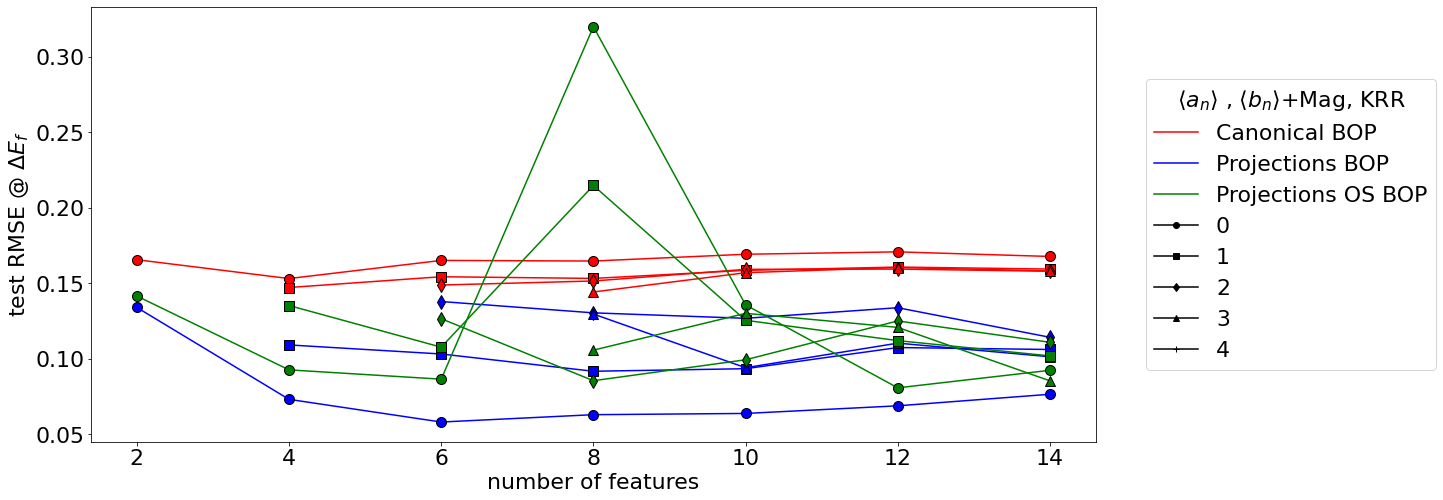

In [41]:
Tester.plot_recursivity_curve(test_scores, ModelName, )

fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{ModelName}_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [42]:
ReducedFittedModels = {}

In [43]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [44]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [45]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [0.1, 0.01, 0.001, 0.0001],
  'regressor__kernel': ['rbf', 'polynomial'],
  'regressor__degree': [4, 5, 6, 7],
  'regressor__coef0': [0, 1, 10]}}

In [46]:
maxorders = [8, 10, 12, 14, 16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  # maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key:
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/120 [00:00<?, ?it/s]

In [47]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [48]:
somecombi = (ModelName, 'Projections BOP')

In [49]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [50]:
features_in = pd.Index(FittedModels[somecombi].feature_names_in_)

In [51]:
features_in.difference(features_in_reduced)

Index([], dtype='object')

In [52]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [53]:
model = best_scores_reduced.index.get_level_values(0)

In [54]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [55]:
test_scores_vs_max[ModelName]

,Projections BOP,Projections OS BOP,Projections sOS BOP,dataset + Projections BOP,dataset + Projections OS BOP,dataset + Projections sOS BOP
8,0.046858,0.039650,0.047285,0.045592,0.039262,0.045957
10,0.046987,0.040995,0.047233,0.044976,0.039894,0.045350
12,0.046778,0.040699,0.047309,0.044464,0.040408,0.045300
14,0.047479,0.040388,0.048048,0.045691,0.041079,0.046303
16,0.047426,0.041194,0.048698,0.046705,0.041894,0.047479


In [56]:
full_model_test_scores = best_scores.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


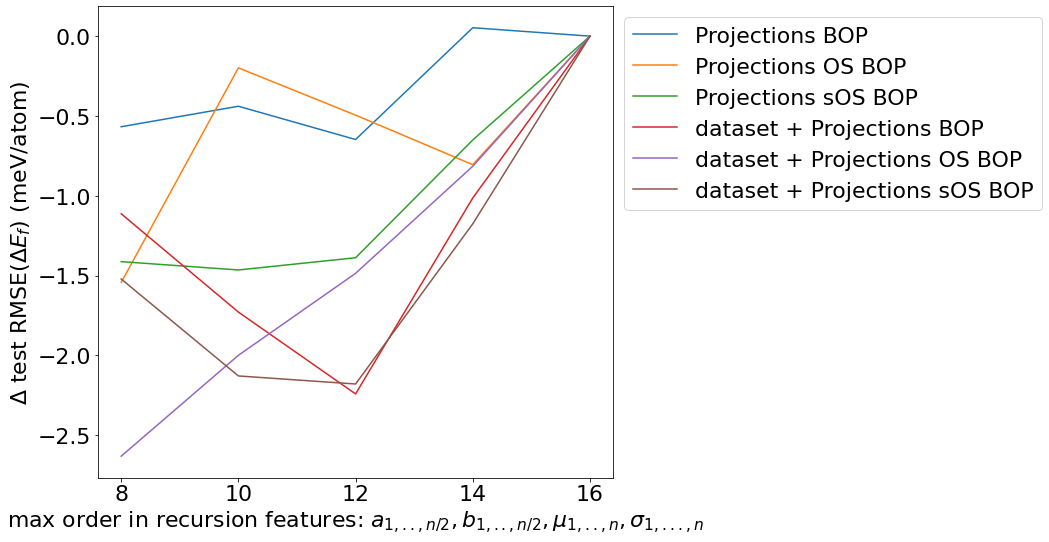

In [57]:
fig, ax = plt.subplots(figsize=(15, 8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values - test_scores_vs_max[combi].values[-1])*1000  # - full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index, drmse, label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1, 1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Feature Concatenation 

In [58]:
FeatureConcatenate = SourceFileLoader('FeatureConcatenate', 'Tools/DatasetTools/FeatureConcatenate.py').load_module().NewFeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate

In [145]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}_fold_train_only.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open(feature_concat_resul_loc, 'rb') as pkl:
        FCresults = pickle.load(pkl)
else:
    FCresults = {}

In [146]:
target_case

'EF_fmbcc'

In [147]:
# iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
# iwanttoplot = ['atomic', 
iwanttoplot = ['ACE', 'SOAP_specific',  'Canonical BOP', 'Projections OS BOP', 'Projections sOS BOP']#, 'SOAP_canonicalW',

(array([35., 14., 35., 35.,  4.,  4.,  8.,  4.,  4.,  9.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

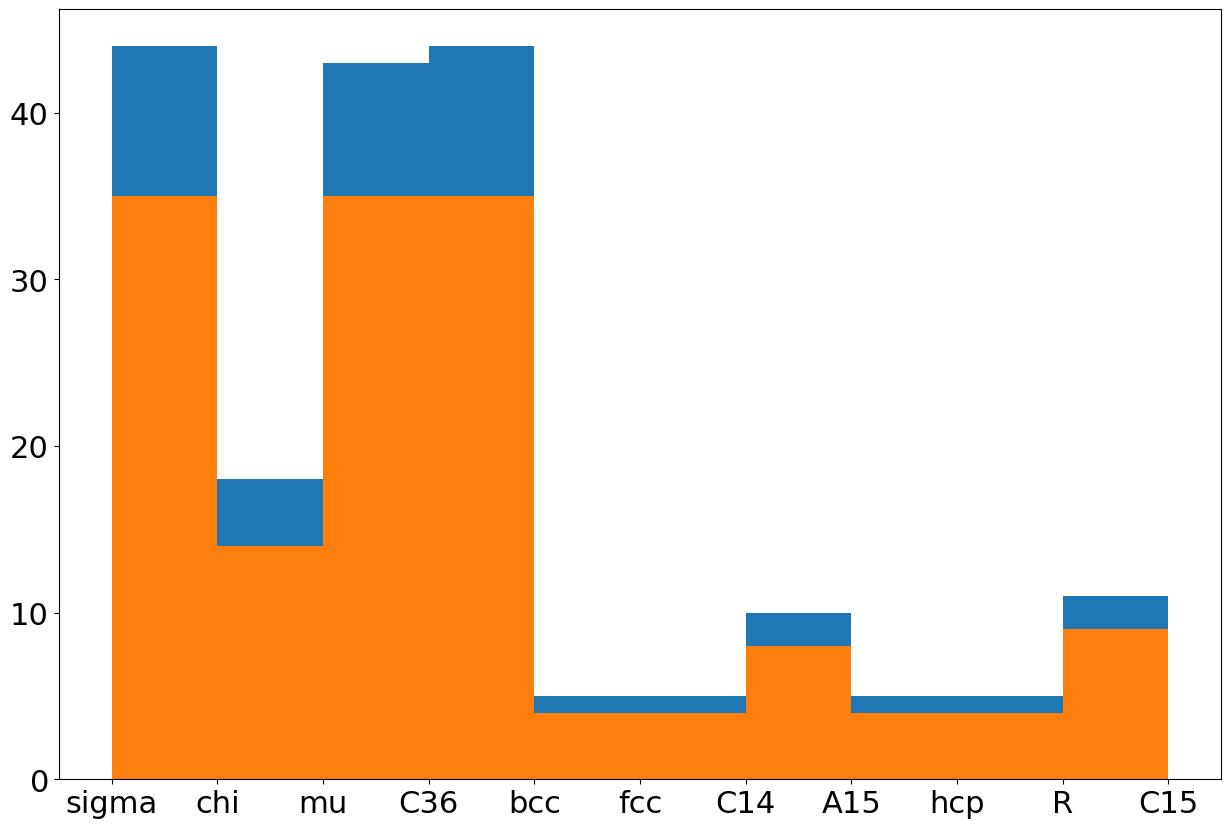

In [174]:
from sklearn.model_selection import StratifiedKFold

test_folder = StratifiedKFold(n_splits = 5, shuffle=True)

test_folds = test_folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])

test_folds_list = list(test_folds)

train_structures = DS.StructureNames[DS.samplesplit['train']]

plt.hist(train_structures)
plt.hist(train_structures.iloc[test_folds_list[0][0]])

In [148]:
# DS.Features.keys(): #['Canonical BOP']:
for combi, fmodel in FittedModels.items():
    if (ModelName not in combi):
        continue
    if combi[-1] not in iwanttoplot:
        continue
    print(combi)
    model = copy.deepcopy(fmodel.best_estimator_)
    if combi in FCresults.keys():
        continue
    FC = FeatureConcatenate(DS, model, fmodel.best_params_,)
    FCresults[combi] = FC.get_best_features_list(combi[1], num_features = DS.Features[combi[1]].shape[1], max_workers=3)
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)

('Kernel Ridge', 'SOAP_specific')
('Kernel Ridge', 'Canonical BOP')
('Kernel Ridge', 'Projections OS BOP')
('Kernel Ridge', 'Projections sOS BOP')
('Kernel Ridge', 'ACE')


In [193]:
from Tools.DatasetTools.Tools import get_str_formatted

In [194]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [195]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

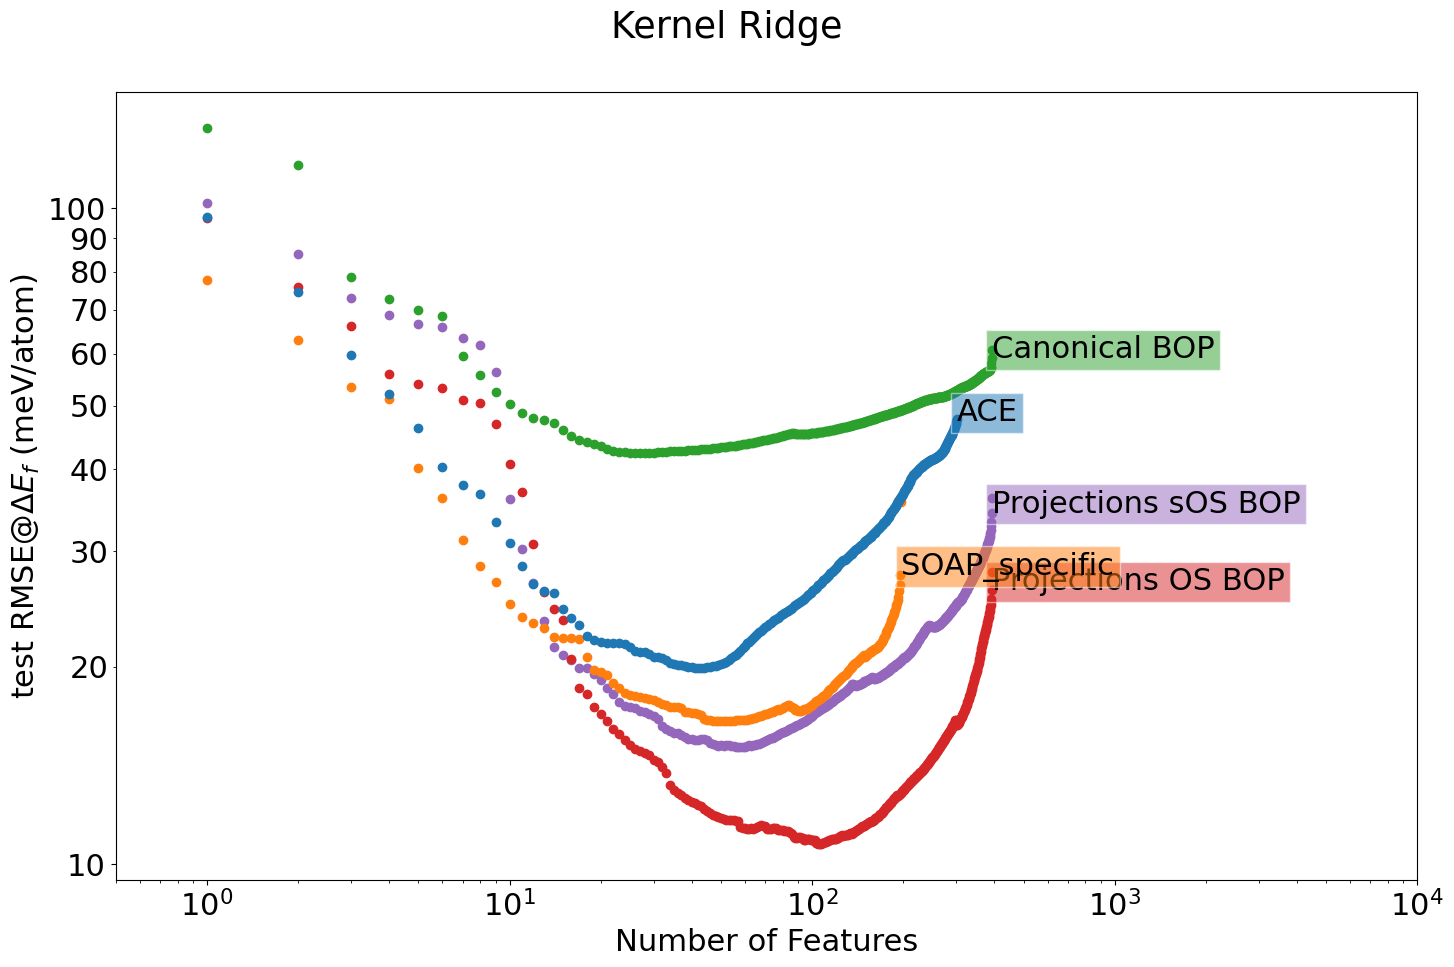

In [196]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(figsize=(15,10))
for combi, result in FCresults.items():
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result.shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')
    y = result['test']*1000
    axes.plot(x, y ,'o',c=colors[combi[1]], label=legend)
    text = axes.text(x[-1], y[-2], legend, horizontalalignment='left')#, backgroundcolor='white', alpha=0.5)
    text.set_bbox(dict(facecolor=colors[combi[1]], alpha=0.5,edgecolor='white'))
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.set_yscale('log')
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
axes.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
axes.set_xlim([0.5, 1e4])
fig.suptitle(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}.pdf')

In [197]:
selected_pos = FCresults[(ModelName, 'Projections sOS BOP')].index[0]
y_pos = FCresults[(ModelName, 'Projections sOS BOP')]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[(ModelName, 'Projections sOS BOP')].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-40), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}.pdf')

## selections

In [198]:
argmin = FCresults[(ModelName, 'Projections OS BOP')]['test'] .argmin()

In [199]:
Features['Projections OS BOP'] [FCresults[(ModelName, 'Projections OS BOP')].index[:argmin]]

,Binf_1_0,sigma_3_CN12,sigma_5_0,bn_3_CN15,bn_2_CN15,sigma_8_CN13,normed_moments_10_CN14,an_4_CN15,Mag,bn_4_CN16,...,an_4_CN14,an_2_CN14,normed_moments_14_CN14,normed_moments_4_CN14,normed_moments_8_CN15,an_1_CN12,an_7_CN15,U_bond_atom_list_1_CN14,sigma_9_CN15,an_3_CN14
Fe_pv14Mo_sv10.C36-AABAB.FM,4.379010,0.023964,-0.290279,0.000000,0.000000,0.000000,0.000000,0.000000,1,1.072878,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-3.558576,0.000000,0.000000,0.000000,0.000000
Fe_pv22Mo_sv8.sigma-AAAAB.FM,3.798044,0.195229,-0.343332,0.309567,0.318192,0.000000,-0.000085,-0.556052,1,0.000000,...,-2.389688,-2.123693,-0.000058,4.063400e-04,-0.000004,-1.905733,-0.568256,-6.390688,-0.026342,-2.476000
Fe_pv14Mo_sv10.C36-ABAAB.FM,4.269807,0.174299,-0.245727,0.000000,0.000000,0.000000,0.000000,0.000000,1,1.052765,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-3.869398,0.000000,0.000000,0.000000,0.000000
Fe_pv18Mo_sv12.sigma-ABBAA.FM,3.333168,0.201138,-0.209064,0.299180,0.378361,0.000000,-0.000295,-0.637160,1,0.000000,...,-2.463107,-2.334043,-0.000152,3.794933e-07,-0.000170,-1.772565,-0.618791,-8.127384,-0.000582,-2.468797
Fe_pv26Mo_sv4.sigma-ABAAA.FM,3.046354,0.189196,-0.257004,0.249699,0.282313,0.000000,-0.000106,-0.656611,1,0.000000,...,-2.729957,-2.364565,-0.000006,-5.340191e-03,0.000024,-2.200237,-0.764726,-1.438158,-0.027424,-3.182043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv24Mo_sv5.chi-BBAA.NM,3.092227,0.216686,-0.206682,0.000000,0.000000,0.017237,0.000000,0.000000,0,0.314345,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-2.629146,0.000000,0.000000,0.000000,0.000000
Fe_pv4Mo_sv2.C15-A2B.NM,3.165963,-0.048619,-0.061148,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.877803,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-4.063933,0.000000,0.000000,0.000000,0.000000
Fe_pv25Mo_sv4.chi-ABAA.NM,2.873821,0.206281,-0.176479,0.000000,0.000000,0.062204,0.000000,0.000000,0,0.302940,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-2.715033,0.000000,0.000000,0.000000,0.000000
Fe_pv16Mo_sv8.C36-BBAAA.NM,3.145756,0.303172,-0.055078,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.822165,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-4.101009,0.000000,0.000000,0.000000,0.000000


# Final learn after feature selection 

In [200]:
OptimalFittedScores = {}
OptimalFittedModels = {}

In [201]:
non_fitted_model[(ModelName, 'Projections OS BOP')]

GridSearchCV(cv=[(array([ 21,  37,  39,  40,  42,  43,  45,  46,  47,  50,  52,  53,  54,
        55,  56,  57,  58,  59,  61,  62,  63,  64,  65,  66,  67,  68,
        69,  70,  71,  73,  74,  75,  76,  77,  78,  80,  81,  82,  83,
        84,  85,  86,  87,  88,  89,  90,  92,  93,  94,  95,  96,  98,
        99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
       112, 113, 114, 115, 116, 119, 120, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140, 141, 142, 14...
       240, 242, 243, 244, 247, 248, 249, 250, 251, 252, 253]))],
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', KernelRidge())]),
             param_grid={'regressor__alpha': [0.1, 0.01, 0.001, 0.0001],
                         'regressor__coef0': [0, 1, 10],
                         'regressor__degree': [4, 5, 6, 7],
                         'regressor__kernel': ['rbf', 'polynomial']},
             return_train_score=True, scoring='neg_root_mean_squared_error',
             verbose=1)

In [202]:
for combi in FCresults.keys():
    if ModelName not in combi:
        continue
    if combi not in FittedModels.keys():
        continue
    print (combi)
    OptimalFittedModels[combi]  = GridSearchCV(
        Models[ModelName],
        param_grid=MO.modeloptions[ModelName], 
        cv = test_folds_list, 
        scoring = 'neg_root_mean_squared_error', n_jobs=3, return_train_score=True)
        #copy.deepcopy(non_fitted_model[combi])
    #params = FittedModels[combi].best_params_
    #OptimalFittedModels[combi].set_params(**params) #= GridSearchCV(amodel, MO.modeloptions[ModelName], scoring = 'neg_root_mean_squared_error',return_train_score=True)
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    if 'random' in selected:
        print(f'random selected in {combi}')
    #if 'random' in selected:
    #    selected = selected.drop('random')
    OptimalFittedModels[combi].fit(X.loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    OptimalFittedScores[combi] = score_fitted_model(OptimalFittedModels[combi], X.loc[DS.samplesplit['train']], X.loc[DS.samplesplit['test']], DS.target[DS.samplesplit['train']], DS.target[DS.samplesplit['test']] )


('Kernel Ridge', 'dataset')
('Kernel Ridge', 'Canonical BOP')
('Kernel Ridge', 'Projections BOP')
('Kernel Ridge', 'atomic')
('Kernel Ridge', 'dataset + Projections BOP')
('Kernel Ridge', 'dataset + Projections OS BOP')
('Kernel Ridge', 'Pyscal')
('Kernel Ridge', 'Projections sOS BOP')
('Kernel Ridge', 'dataset + Canonical BOP')
('Kernel Ridge', 'dataset + Projections sOS BOP')
('Kernel Ridge', 'Projections OS BOP')
('Kernel Ridge', 'SOAP_canonicalFe')
('Kernel Ridge', 'SOAP_canonicalW')
('Kernel Ridge', 'SOAP_specific')
('Kernel Ridge', 'ACE')


In [203]:
OptimalFittedScores = pd.DataFrame.from_dict(OptimalFittedScores, orient='index')#.sort_values(by='test')
OptimalFittedScores.sort_values(by='test', ascending=False, inplace=True)

In [204]:
OptimalFittedFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalModels_{target_case}.pkl'
with open(OptimalFittedFile, 'wb') as pkl:
    pickle.dump(OptimalFittedModels, pkl)
OptimalFittedScoresFile = f'{DS.dataset}/results/{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'
with open(OptimalFittedScoresFile, 'wb') as pkl:
    pickle.dump(OptimalFittedScores, pkl)


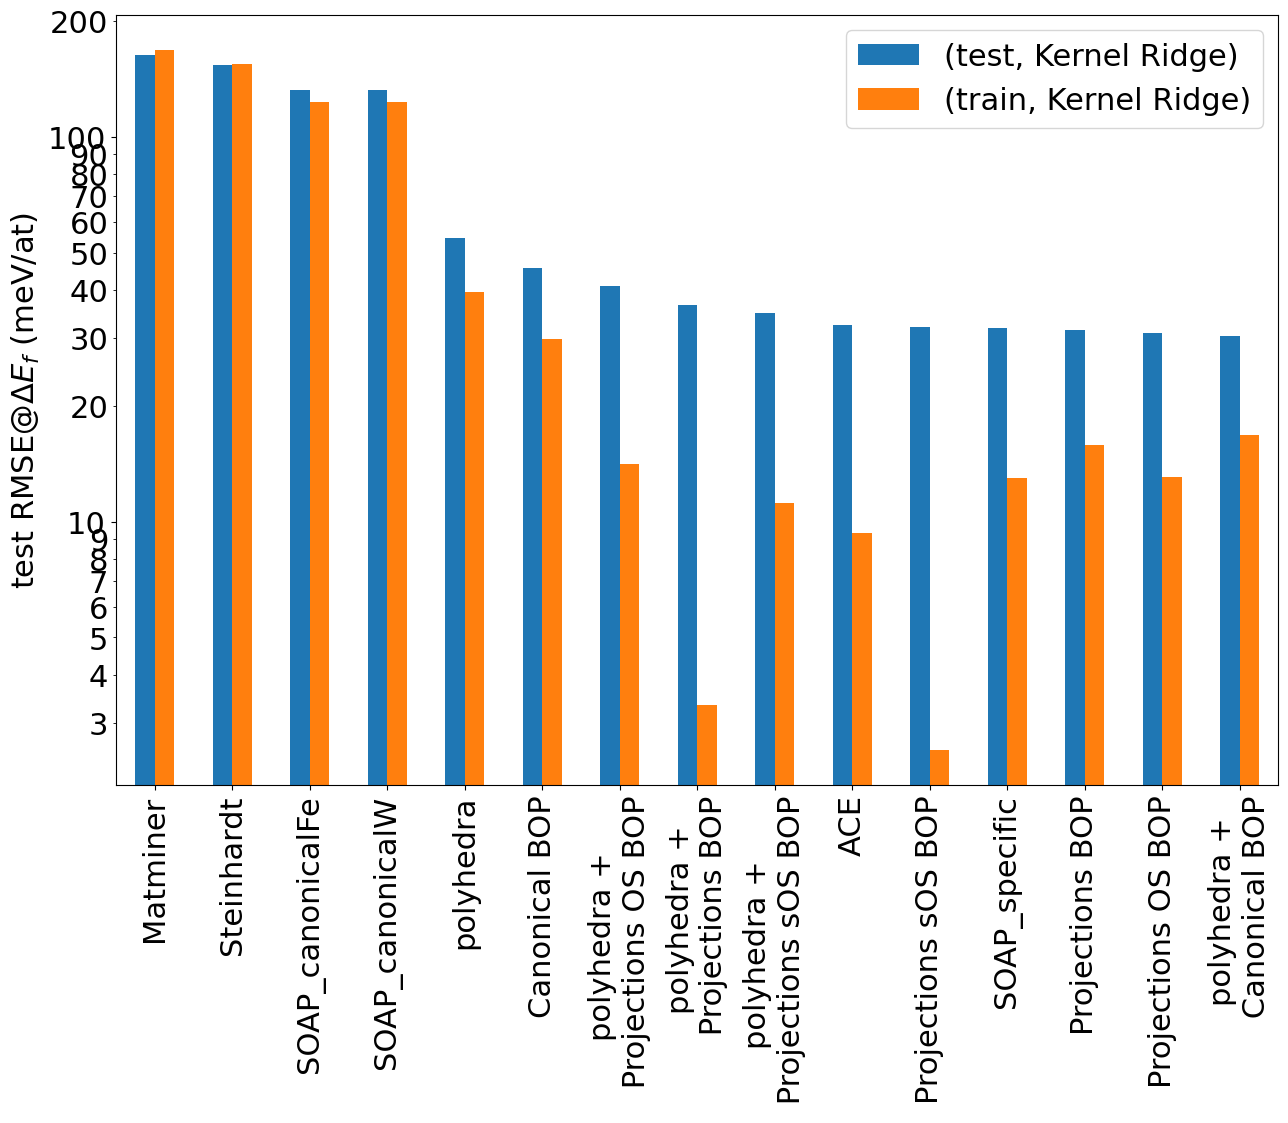

In [205]:
plot_best_scores = SourceFileLoader('plot_best_scores', 'Tools/DatasetTools/MLConveniences.py').load_module().plot_best_scores

ax = plot_best_scores(OptimalFittedScores, ModelName=ModelName)
ax.tick_params(axis='y', which = 'minor')
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.legend(title='')

# Prediction line 

In [206]:
Prediction = {}
for combi, model in OptimalFittedModels.items():
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    X = DS.Features[combi[1]][selected]
    Prediction[combi] = model.predict(X)

In [207]:
#iwanttoplot = {'atomic':'Matminer',
#iwanttoplot = {'Canonical BOP': 'Canonical BOP', 'Projections sOS BOP':'Projections sOS BOP'}
iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

In [208]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)

dataset dataset


KeyError: 'dataset'

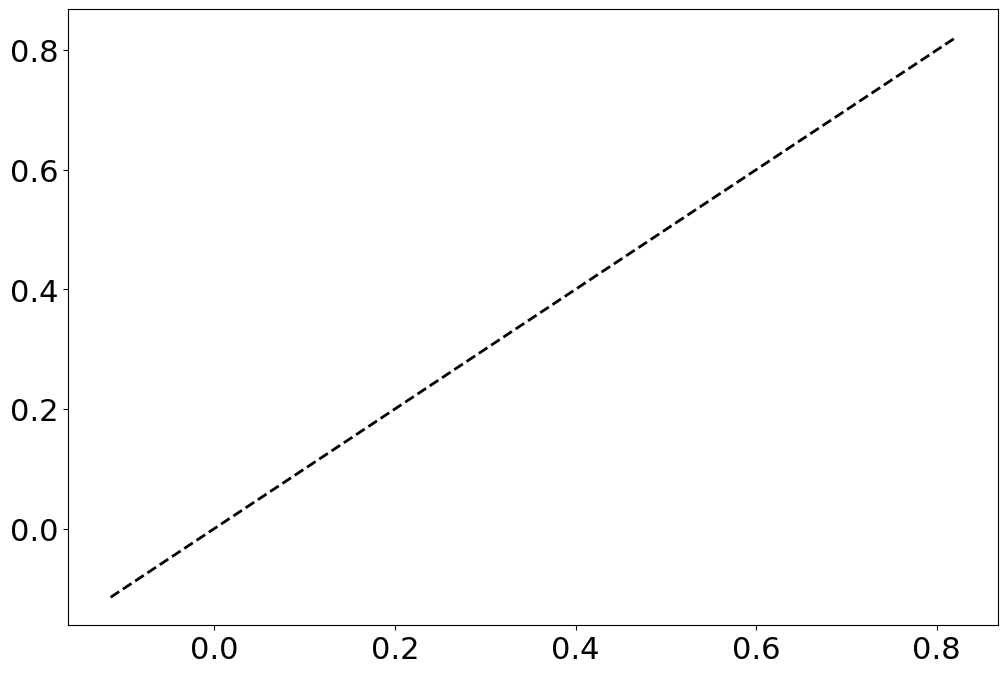

In [209]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi], DS.target, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend)
#    sns.scatterplot(Prediction[name], DS.target,ax=ax) #, markersize=8, markeredgecolor='k',  color = color, label=legend)
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

# Feature Importances 

In [ ]:
importances = {}
for combi, estimator in OptimalFittedModels.items():
    print(combi[1])
    atmin = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:atmin]
    if 'random' in selected:
        print(f'random selected in {combi}')
    X = DS.Features[combi[1]][selected]
    allimportances = get_importances(estimator , X,  DS.target)
    importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]

In [ ]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)

In [ ]:
#for (model, name), timp in importances.items():
for (model, name), timp in importances.items(): #['Projections OS BOP', 'dataset + Projections OS BOP']:
#    pimp = timp[timp.index != 'Mag']
    fig, ax = plt.subplots(figsize=(18, 15))
    x = timp['importances_mean'][:20]
    sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
    ylabels = [get_str_formatted(fname) for fname in x.index]
    ax.set_xlabel('permutation importance')
    ax.set_yticklabels(ylabels, fontsize=28)
    fig.suptitle(name.replace('dataset', 'polyhedra'))
    fig.tight_layout()
    nameforfile  = name.replace(' ','')
    fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_permutation_importance_{nameforfile}.pdf')

# Errors by phase by model

In [238]:
train_errors = {}
rmse = {}

In [240]:
for combi, model in OptimalFittedModels.items():
#combi = (ModelName, 'Projections OS BOP')
#model = OptimalFittedModels[combi]
    nselected = FCresults[combi]['test'].argmin()
    selected = FCresults[combi].index[:nselected]
    predictions = model.predict(DS.Features[combi[1]][selected])
    train_errors[combi] = np.abs(predictions - DS.target)
    rmse[combi] = {}
    for phase in DS.BS.Phase.unique():
        thiserrors = train_errors[DS.BS.Phase == phase]**2
        rmse[combi][phase] =  np.sqrt(thiserrors.sum()/len(thiserrors))*1000

TypeError: unhashable type: 'Series'

<AxesSubplot:xlabel='EF_fmbcc', ylabel='Phase'>

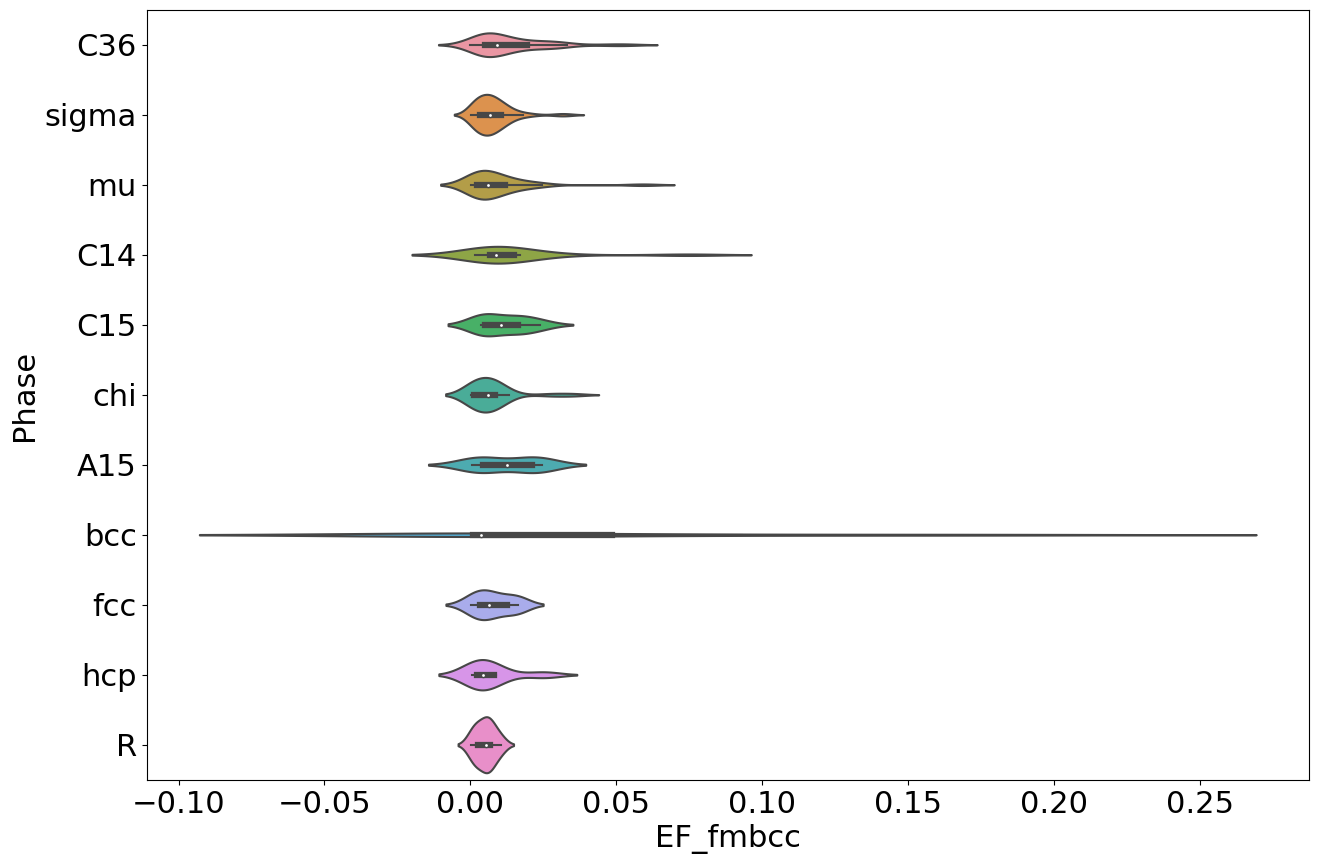

In [235]:
sns.violinplot(x = train_errors, y = DS.StructureNames)

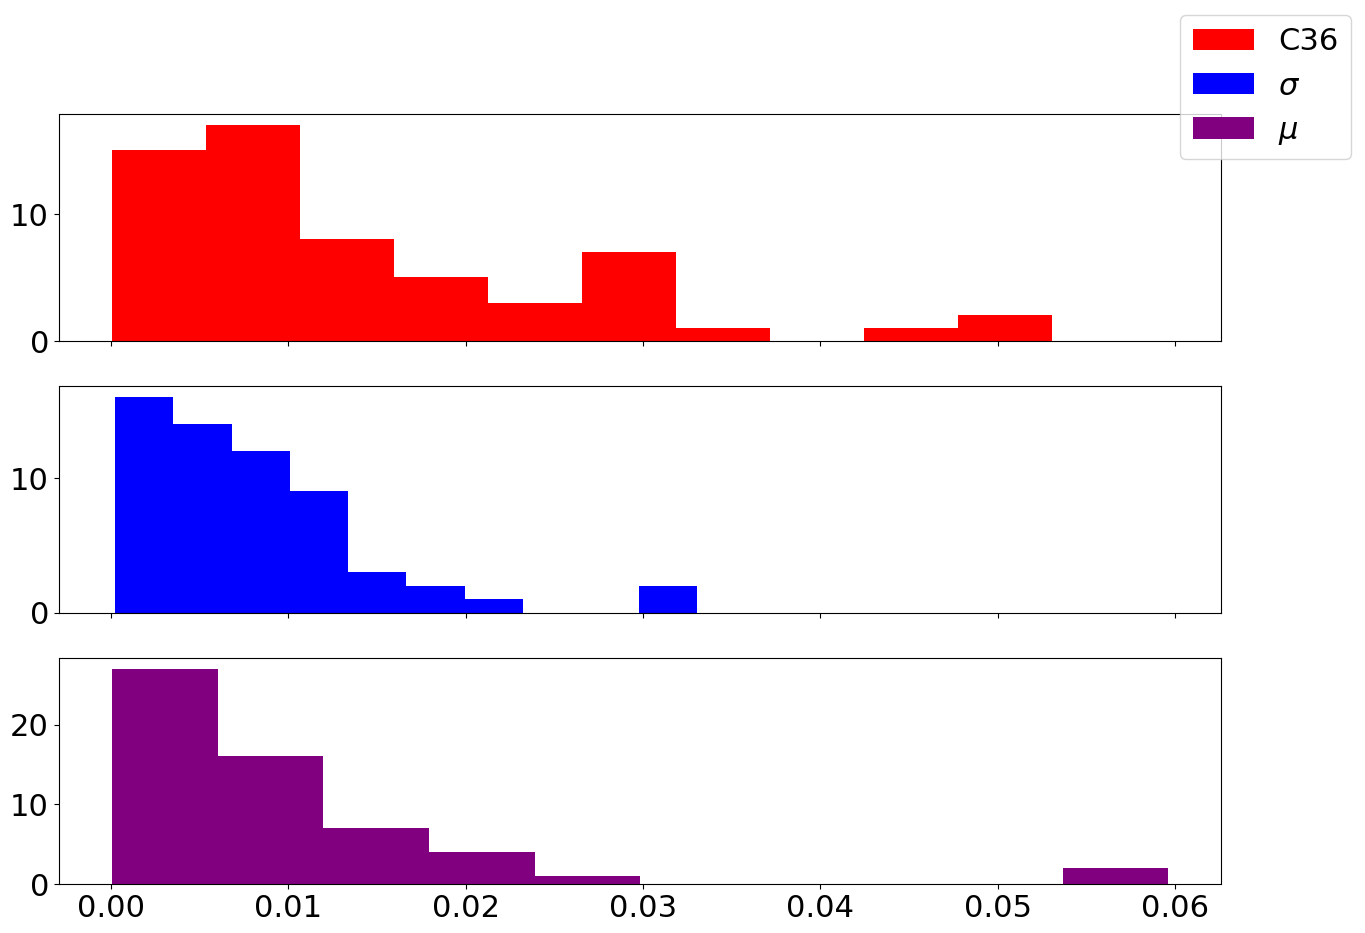

In [218]:
fig, ax = plt.subplots(3, 1, sharex = True)
tphase = ax[0].hist(train_errors[DS.BS.Phase == 'C36'], bins=10, color='red', label='C36')
tphase = ax[1].hist(train_errors[DS.BS.Phase == 'sigma'], bins=10,color='blue', label = r'$\sigma$')
tphase = ax[2].hist(train_errors[DS.BS.Phase == 'mu'], bins=10, color='purple', label = r'$\mu$')
fig.legend()

# Errors by Mag 

In [ ]:
fm_errors = train_errors[train_errors.index.str.contains('FM$',regex=True)]

In [ ]:
nm_errors = train_errors[train_errors.index.str.contains('NM$',regex=True)]

In [ ]:
ax = nm_errors.hist()
fm_errors.hist(ax=ax)
ax.set_xlabel(r'$\Delta E_{FM} - \Delta E_{NM}$')

# convex hulls (binaries only)

In [ ]:
from Tools.DatasetTools.Tools import Plotting
P = Plotting()

In [ ]:
from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

In [ ]:
components = DS.components

In [ ]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [ ]:
predictedBS['EF'] = Prediction[combi]

In [ ]:
PhaseBS = {}
verts = {}
chulls = {}
phasepoints = {}

PhaseBS = {phase: DS.BS[DS.BS.Phase == phase] for phase in DS.BS.Phase.unique()}

points = P.get_x_ef_points(PhaseBS, components)
chulls = P.get_convex_hulls(PhaseBS, components, return_points = False)

In [ ]:
PredPhaseBS = {}
Predverts = {}
Predchulls = {}
Predphasepoints = {}

PredPhaseBS = {phase: predictedBS[DS.BS.Phase == phase] for phase in DS.BS.Phase.unique()}

predpoints = P.get_x_ef_points(PredPhaseBS, components)
predchulls = P.get_convex_hulls(PredPhaseBS, components, return_points = False)

In [ ]:
iwanttoplot_inchull = ['R', 'mu', 'C14', 'C36','sigma']

In [ ]:
pallette = sns.color_palette("icefire", n_colors=len(iwanttoplot))
colors = {phase: color for phase, color in zip(iwanttoplot, pallette)}
fig, ax = plt.subplots()
labels=[]
handles = []
for phase, chull in chulls.items():
    if phase not in iwanttoplot_inchull:
        continue
    for visible_facet in chull.simplices[chull.good]:
#        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase], lw=2)
    handles.append(l[0])
    labels.append(phase)
    for visible_facet in predchulls[phase].simplices[predchulls[phase].good]:
#        ax.plot(points[phase][:,0] , points[phase][:,1], 'o', color = colors[phase])
        l = ax.plot(predchulls[phase].points[visible_facet,0], predchulls[phase].points[visible_facet,1],'--o', color=colors[phase], lw=2, ms=10)
leg = ax.legend(handles +[Line2D([],[], linestyle='--',marker='o', color='black')], labels+[f'{ModelName} \n Predictions'], bbox_to_anchor=(1.01,1))
setlw = [ha.set_linewidth(5) for ha in leg.get_lines()[:-1] ]
ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
ax.set_xlabel(rf'$x_{{{components[0]}}}$')
ax.axhline(color='black', linestyle='--')
ax.set_xlim([0,1])
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(os.path.join(DS.dataset, 'graphs',f'{DS.dataset}_{nameforfile}_ConvxHullsFinal_{target_case}.eps' ))